In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split


In [44]:
df = pd.read_csv("D:\DEV VELLY\Datasets\salary_dataset.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_16252\2601176861.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DEV VELLY\Datasets\salary_dataset.csv")


,Position,Level,Salary
0,Partner,7,575017
1,Manager,4,223952
2,Senior Partner,8,688867
3,Country Manager,5,333069
4,Partner,7,552960


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [47]:
X = df[['Level']]
y = df['Salary']

In [48]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state = 40)
x_test.shape

(200, 1)

In [49]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(X)

In [50]:
poly_feature = PolynomialFeatures(degree=2)
x_poly_train = poly_feature.fit_transform(x_train)
x_poly_all = poly_feature.transform(X)

poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)

y_pred_poly = poly_model.predict(x_poly_all)


In [51]:
X.ndim

2

c:\Users\HASEEB\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


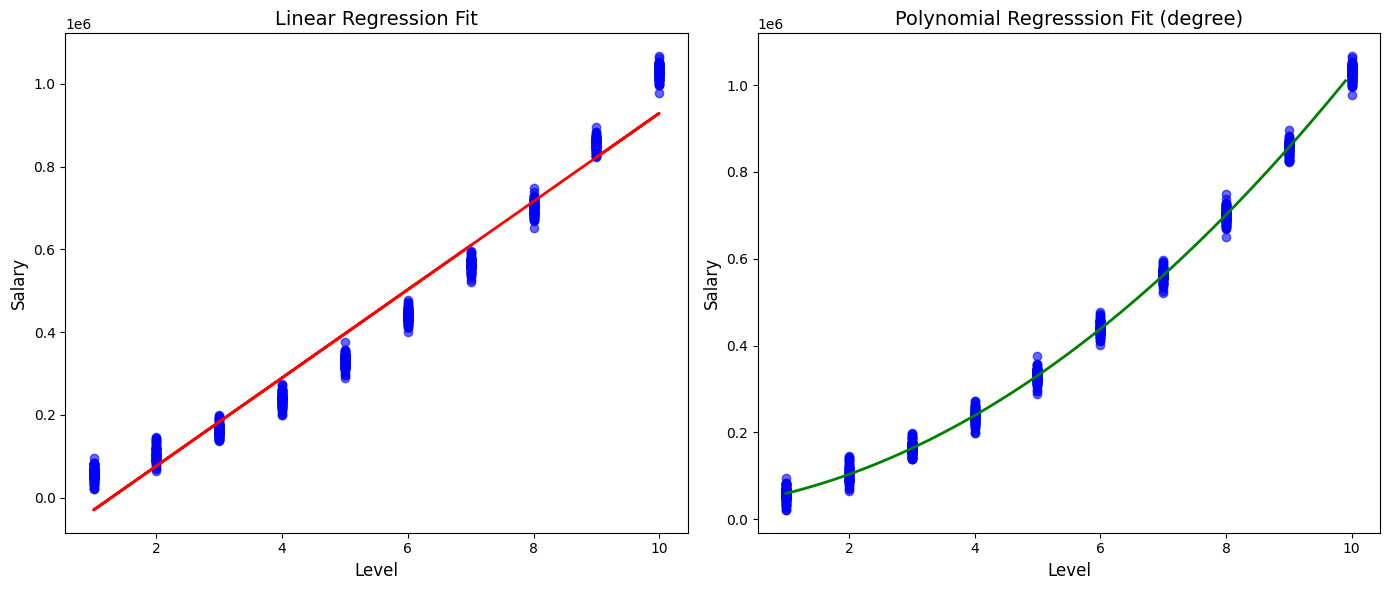

In [ ]:
x_smooth = np.arange(X['Level'].min(), X['Level'].max(), 0.1)
x_smooth = x_smooth.reshape(-1, 1)

plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)

plt.scatter(X, y, color = "blue", alpha = 0.6)
plt.plot(X, y_pred_linear, color = "red", linewidth = 2)

plt.title("Linear Regression Fit", fontsize = 14)
plt.xlabel("Level", fontsize = 12)
plt.ylabel("Salary", fontsize = 12)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color = "blue", alpha = 0.6)
plt.plot(x_smooth, poly_model.predict(poly_feature.transform(x_smooth)), color = "green", linewidth = 2)
plt.title("Polynomial Regresssion Fit (degree)", fontsize = 14)
plt.xlabel("Level", fontsize = 12)
plt.ylabel("Salary", fontsize = 12)

plt.tight_layout()

plt.show()